In [ ]:
import pandas as pd
from matplotlib import pyplot as plt


from keras.models import Sequential
from keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [58]:
# Load dataset

df = pd.read_csv('co2.csv')
df.head(10)

,engine,cylandr,fuelcity,fuelwy,fuelcomb,out1
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244
5,3.5,6,11.9,7.7,10.0,230
6,3.5,6,11.8,8.1,10.1,232
7,3.7,6,12.8,9.0,11.1,255
8,3.7,6,13.4,9.5,11.6,267
9,2.4,4,10.6,7.5,9.2,212


In [59]:
df.describe()

,engine,cylandr,fuelcity,fuelwy,fuelcomb,out1
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,522.000000


In [60]:
# Build neural network
 
model = Sequential()
model.add(Dense(20, input_dim= 5, activation= 'relu'))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer="adam", metrics=["mean_squared_error"])

c:\Users\Matin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 20)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [62]:
from keras_visualizer import visualizer
visualizer(model, file_name="model_DL", file_format="png")

In [63]:
# Preprocess data

X = df.drop('out1',axis=1)
y = df.out1

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [ ]:
'''
note: If you normalize your data, the output will be slightly better, 
in addition, you will reach the final output with less training.
'''
# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

'\nnote: if you normalize your data the output be a little better, in addition, with less training you will reach the outsame output\n'

In [66]:
# Train model

history = model.fit(
                    X_train,
                    y_train, 
                    epochs=200,
                    verbose= 1)

Epoch 1/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 58350.7070 - mean_squared_error: 58350.7070
Epoch 2/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39765.6562 - mean_squared_error: 39765.6562
Epoch 3/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19052.7930 - mean_squared_error: 19052.7930
Epoch 4/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5860.3960 - mean_squared_error: 5860.3960
Epoch 5/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1357.8693 - mean_squared_error: 1357.8693
Epoch 6/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 597.9805 - mean_squared_error: 597.9805
Epoch 7/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 537.4144 - mean_squared_error: 537.4144
Epoch 8/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 535.1151 - mean_squared_error: 535.1151
Epoch 9/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 534.5327 - mean_squared_error: 534.5327
Epoch 10/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 533.9900 - me

In [67]:
y_pred = model.predict(X_test, verbose= 0)
y_pred

array([[254.54518],
       [342.6994 ],
       [326.89633],
       ...,
       [183.614  ],
       [240.02046],
       [193.59286]], dtype=float32)

In [68]:
y_test

7261    253
4489    344
1539    322
3532    297
6418    308
       ... 
7185    221
1740    260
4609    184
1844    235
5154    193
Name: out1, Length: 1477, dtype: int64

In [69]:
# Evaluate

print("metrics.mean_squared_error= ", mean_squared_error(y_test, y_pred))
print("mean_squared_error= ", history.history['loss'][-1])

metrics.mean_squared_error=  231.20274795122376
mean_squared_error=  212.7855682373047


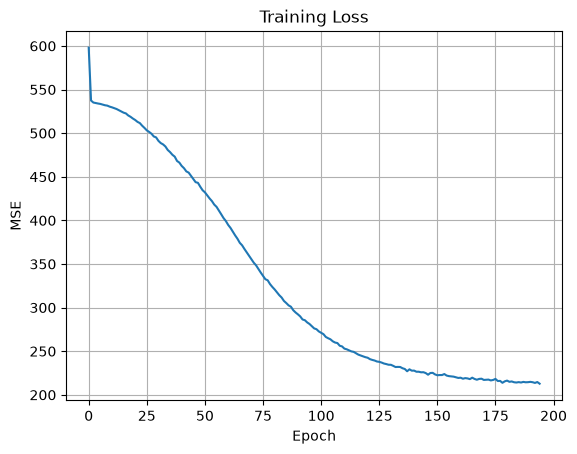

In [70]:
# Visualize

er=history.history['loss']
er=er[5:]
plt.close()
plt.plot(er)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()